In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvbHVjYS9Eb2t1bWVudGUvZGV2L2FyYmVpdC9sdWNhaC50ZWNoL3F1b3RlbWUuZ2l0aHViLmlvL3Bvc3RzL2NvbW11dGF0b3I='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/importlib/_bootstrap.py": 1746706798.1099684, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/importlib/_bootstrap_external.py": 1746706798.1109684, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/zipimport.py": 1746706798.599966, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/codecs.py": 1746706797.6719706, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/encodings/aliases.py": 1746706797.7389703, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/encodings/__init__.py": 1746706797.7359703, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/encodings/utf_8.py": 1746706797.79997, "/home/luca/.local/share/uv/python/cpython-3.13.3-linux-x86_64-gnu/lib/python3.13/abc.py": 1746706797.6389706, "/home/luca/.local/sh

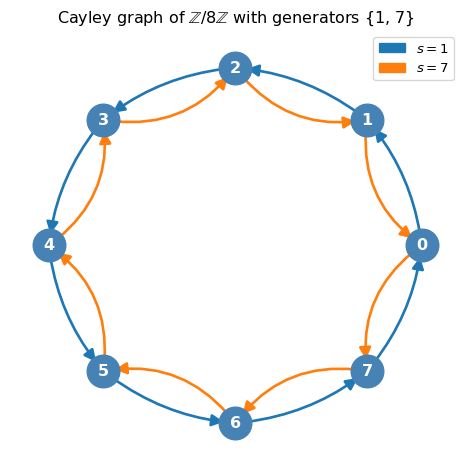

In [2]:
#| label: cayley-graph-cyclic
#| fig-cap: Cayley graph of $\mathbb{Z}/m\mathbb{Z}$ with generators $S = \{1, m-1\}$
#| fig-align: center
#| code-fold: true
#| code-summary: 'Show code: Cayley graph of ℤ/mℤ'
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_cayley_graph_cyclic(m: int, generators: list[int] | None = None) -> None:
    """
    Draw the Cayley graph of Z/mZ with respect to a given generating set.

    Parameters
    ----------
    m : int
        The modulus, i.e. the order of the group Z/mZ.
    generators : list of int, optional
        A list of generators (elements of Z/mZ). Defaults to {1, m-1}.
    """
    if generators is None:
        generators = [1, m - 1]

    G = nx.MultiDiGraph()
    G.add_nodes_from(range(m))
    for s in generators:
        for g in range(m):
            G.add_edge(g, (g + s) % m, generator=s)

    # Place nodes evenly on a circle
    pos = {
        i: (np.cos(2 * np.pi * i / m), np.sin(2 * np.pi * i / m))
        for i in range(m)
    }

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    fig, ax = plt.subplots(figsize=(5, 5))

    nx.draw_networkx_nodes(G, pos, node_color="steelblue", node_size=600, ax=ax)
    nx.draw_networkx_labels(
        G, pos,
        labels={i: str(i) for i in range(m)},
        font_color="white", font_weight="bold", ax=ax,
    )

    for idx, s in enumerate(generators):
        edges = [(g, (g + s) % m) for g in range(m)]
        nx.draw_networkx_edges(
            G, pos, edgelist=edges,
            edge_color=colors[idx % len(colors)],
            arrows=True, arrowsize=18, width=2,
            connectionstyle=f"arc3,rad={0.15 * (idx + 1)}",
            ax=ax,
        )

    legend_handles = [
        mpatches.Patch(color=colors[i % len(colors)], label=f"$s = {s}$")
        for i, s in enumerate(generators)
    ]
    ax.legend(handles=legend_handles, loc="upper right")
    ax.set_title(
        rf"Cayley graph of $\mathbb{{Z}}/{m}\mathbb{{Z}}$"
        f" with generators {set(generators)}"
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()

draw_cayley_graph_cyclic(m=8)

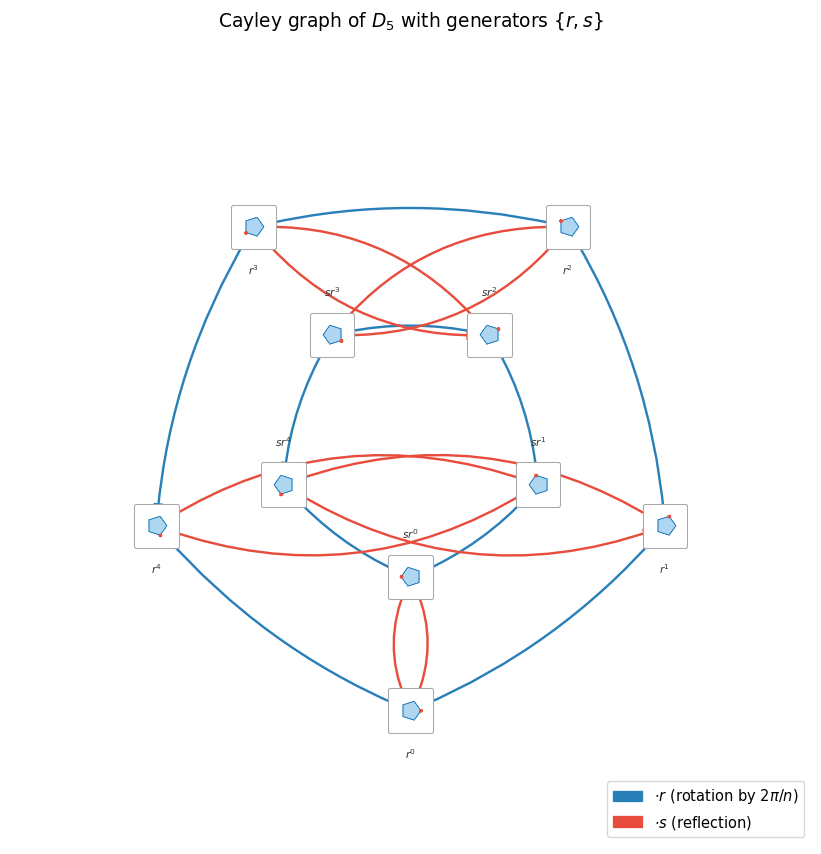

In [3]:
#| label: cayley-graph-dihedral
#| fig-cap: Cayley graph of $D_n$ with generators $\{r, s\}$
#| fig-align: center
#| code-fold: true
#| code-summary: 'Show code: Cayley graph of D_n'
import io
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import AnnotationBbox, OffsetImage


def make_polygon_image(n: int, rotation: float, reflected: bool, size: int = 80) -> np.ndarray:
    """Render a small RGBA image of a regular n-gon in its current symmetry state."""
    dpi = size
    fig_s, ax_s = plt.subplots(figsize=(1, 1), dpi=dpi)
    ax_s.set_xlim(-1.6, 1.6)
    ax_s.set_ylim(-1.6, 1.6)
    ax_s.set_aspect("equal")
    ax_s.axis("off")
    fig_s.patch.set_alpha(0)
    ax_s.patch.set_alpha(0)

    angles = np.linspace(0, 2 * np.pi, n, endpoint=False) + rotation
    x = np.cos(angles)
    y = np.sin(angles)
    if reflected:
        x = -x  # reflect across y-axis

    polygon = plt.Polygon(
        list(zip(x, y)),
        closed=True,
        facecolor="#aed6f1",
        edgecolor="#2e86c1",
        linewidth=2,
    )
    ax_s.add_patch(polygon)
    # Mark vertex 0 with a red dot to track orientation
    ax_s.plot(x[0], y[0], "o", color="#e74c3c", markersize=6, zorder=5)

    fig_s.canvas.draw()
    buf = fig_s.canvas.buffer_rgba()
    img = np.frombuffer(buf, dtype=np.uint8).reshape(
        fig_s.canvas.get_width_height()[::-1] + (4,)
    ).copy()
    plt.close(fig_s)
    return img


def draw_cayley_graph_dihedral(n: int) -> None:
    """
    Draw the Cayley graph of the dihedral group D_n (order 2n)
    with generators r (rotation by 2π/n) and s (a fixed reflection).

    Elements are represented as pairs (k, f) where
      k ∈ ℤ/nℤ  is the rotation exponent,
      f ∈ {0,1} indicates whether a reflection has been applied.
    So (k, 0) = r^k  and  (k, 1) = s·r^k.

    Right-multiplication rules:
      (k, f) · r  =  (k+1 mod n,   f)
      (k, 0) · s  =  (n-k mod n,   1)
      (k, 1) · s  =  (n-k mod n,   0)
    """
    nodes = [(k, f) for f in range(2) for k in range(n)]
    node_index = {node: i for i, node in enumerate(nodes)}

    G = nx.MultiDiGraph()
    G.add_nodes_from(range(len(nodes)))

    for k in range(n):
        for f in range(2):
            # right-multiply by r
            G.add_edge(node_index[(k, f)], node_index[((k + 1) % n, f)], gen="r")
        # right-multiply by s
        G.add_edge(node_index[(k, 0)], node_index[((n - k) % n, 1)], gen="s")
        G.add_edge(node_index[(k, 1)], node_index[((n - k) % n, 0)], gen="s")

    # Two concentric rings: outer = rotations (f=0), inner = reflections (f=1)
    outer_r, inner_r = 2.8, 1.4
    pos = {}
    for k in range(n):
        angle = 2 * np.pi * k / n - np.pi / 2
        pos[node_index[(k, 0)]] = (outer_r * np.cos(angle), outer_r * np.sin(angle))
        pos[node_index[(k, 1)]] = (inner_r * np.cos(angle), inner_r * np.sin(angle))

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.set_xlim(-4.2, 4.2)
    ax.set_ylim(-4.2, 4.2)
    ax.set_aspect("equal")
    ax.axis("off")

    r_edges = [(u, v) for u, v, d in G.edges(data=True) if d["gen"] == "r"]
    s_edges = [(u, v) for u, v, d in G.edges(data=True) if d["gen"] == "s"]

    nx.draw_networkx_edges(
        G, pos, edgelist=r_edges,
        edge_color="#2980b9", arrows=True, arrowsize=14, width=1.8,
        connectionstyle="arc3,rad=0.12", ax=ax,
    )
    nx.draw_networkx_edges(
        G, pos, edgelist=s_edges,
        edge_color="#e74c3c", arrows=True, arrowsize=14, width=1.8,
        connectionstyle="arc3,rad=0.25", ax=ax,
    )

    zoom = 0.38
    for node_id, (k, f) in enumerate(nodes):
        img = make_polygon_image(n, rotation=2 * np.pi * k / n, reflected=bool(f))
        imagebox = OffsetImage(img, zoom=zoom)
        ab = AnnotationBbox(imagebox, pos[node_id], frameon=True,
                            bboxprops=dict(boxstyle="round,pad=0.15",
                                          facecolor="white", edgecolor="#aaaaaa",
                                          linewidth=0.8))
        ax.add_artist(ab)

        # Label node below the image
        label = rf"$r^{k}$" if f == 0 else rf"$sr^{k}$"
        x, y = pos[node_id]
        offset = -0.45 if f == 0 else 0.45
        ax.text(x, y + offset, label, ha="center", va="center", fontsize=8,
                color="#333333")

    legend_handles = [
        mpatches.Patch(color="#2980b9", label=r"$\cdot r$ (rotation by $2\pi/n$)"),
        mpatches.Patch(color="#e74c3c", label=r"$\cdot s$ (reflection)"),
    ]
    ax.legend(handles=legend_handles, loc="lower right", fontsize=11)
    ax.set_title(
        rf"Cayley graph of $D_{{{n}}}$ with generators $\{{r, s\}}$",
        fontsize=14, pad=12,
    )
    plt.tight_layout()
    plt.show()


draw_cayley_graph_dihedral(n=5)